# Visium_MOB

In [1]:
import warnings
warnings.filterwarnings("ignore")
import MENDER
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.metrics import *
import time

In [2]:
## load the data using pysodb, please install pysodb in advance [https://pysodb.readthedocs.io/en/latest/]
import pysodb
sodb = pysodb.SODB()
adata_raw = sodb.load_experiment('Lebrigand2022The','GSM4656181_10x_Visium')


load experiment[GSM4656181_10x_Visium] in dataset[Lebrigand2022The]


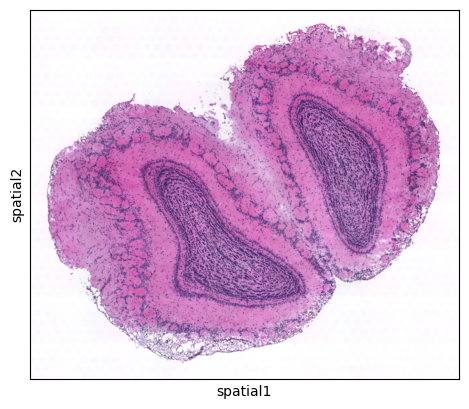

In [3]:
ax = sc.pl.spatial(adata_raw,color=None,show=False)


In [4]:






adata = adata_raw.copy()



######### determine cell state using standard Leiden [start]  #########
# this step can be optionally skipped if reliable cell type annotation is available
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=4000)
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)

sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata,resolution=2,key_added='ct')
adata.obs['ct'] = adata.obs['ct'].astype('category')
######### determine cell state using standard Leiden [end]  #########







In [5]:
# input parameters of MENDER
scale = 2

# main body of MENDER
msm = MENDER.MENDER_single(
    adata,
    # determine which cell state to use
    # we use the cell state got by Leiden
    ct_obs='ct'
)


# set the MENDER parameters


msm.set_MENDER_para(
    # default of n_scales is 6
    n_scales=scale, 
    
    # for single cell data, nn_mode is set to 'radius' 
    # for spot data, nn_mode is set to 'ring', since each spot is surrounded by certain number of spots (6 for visium and 4 for ST)
    
    nn_mode='ring',
    
    # default of n_scales is 15 um (see the manuscript for why).
    # MENDER also provide a function 'estimate_radius' for estimating the radius
    # if nn_mode is set to 'ring', nn_para means the number of spots around the central spot, i.e., 6 for Visium and 4 for ST
    nn_para=6, 

)
# construct the context representation
msm.run_representation(
    
    # the number of processings
)

# set the spatial clustering parameter
# positive values for the expected number of domains
# negative values for the clustering resolution
msm.run_clustering_normal(-0.2)



scale 0, median #cells per ring (r=6): 7.0
scale 1, median #cells per ring (r=6): 12.0


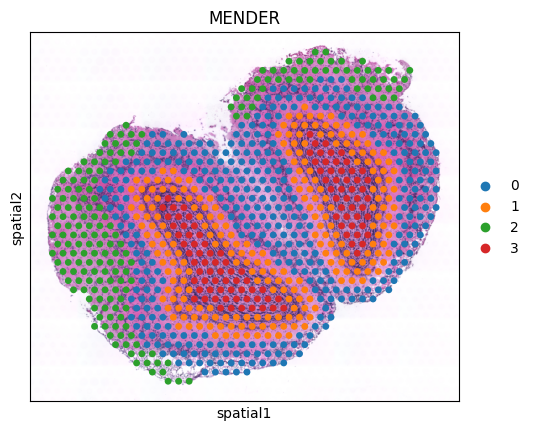

In [6]:
sc.pl.spatial(msm.adata_MENDER,color='MENDER',size=1)

In [7]:
msm.adata_MENDER.write_h5ad('dump/Visium_MOB.h5ad')

